In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import sys
sys.path.append('../../')
from scripts.resgen.logmaps.config_logmapres import final_res_path, figure_path

Matplotlib created a temporary cache directory at /tmp/matplotlib-dm6sir2d because the default path (/home/zsiga/.config/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


## Functions

In [6]:
def integrate_somdata(df, som_df, dataset='', method='SOM'):
    som_df.columns = ['r']
    som_df[['method']] = method
    som_df[['dataset']] = dataset
    # reset index, but save it as data_id
    som_df.reset_index(inplace=True)
    som_df.rename(columns={'index': 'data_id'}, inplace=True)

    # add the data to the dataframe
    df = pd.concat([df, som_df], ignore_index=True, axis=0)
    return df

def sort_by_med(df):
    # Group by method and compute median
    grouped = df[['method', 'r']].groupby('method')
    df2 = pd.DataFrame({col:vals['r'] for col,vals in grouped},)
    meds = df2.median().sort_values(ascending=True, inplace=False)
    df2 = df2[meds.index]
    return df2

def plot_res(df2, highlight=[''], filename=None):
    # Plot
    fs = 20
    ticksize = 16
    # set color by method one by one

    palette = {method : 'tab:green' if method in highlight else 'tab:blue' for method in df2.columns }
    

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.boxplot(df2, palette=palette, ax=ax)
    sns.swarmplot(data=df2, color=".25", size=3, ax=ax)

    ax.set_ylim(-0.05, 1.05)
    ax.grid(True)

    ax.set_ylabel(r'Abs. Pearson Correlation $|\rho|$', size=fs)
    ax.set_xlabel(r'Method', size=fs)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right', fontsize=ticksize)
    ax.set_yticklabels([r'{:.1f}'.format(i) for i in ax.get_yticks()], fontsize=ticksize)


    plt.tight_layout()
    if filename is not None:
        plt.savefig(filename, dpi=300)
    return fig, ax

def plot_on_ax(df, ax, palette):
    fs = 14
    ticksize = 12

    sns.boxplot(df, palette=palette, ax=ax)
    sns.swarmplot(data=df, color=".25", size=3, ax=ax)
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True)

    ax.set_ylabel(r'Abs. Pearson Correlation $|\rho|$', size=fs)
    ax.set_xlabel(r'Method', size=fs)
    ax.set_xticklabels(ax.get_xticklabels(),
                       rotation=45,
                       verticalalignment='top', 
                       horizontalalignment='right',
                       fontsize=ticksize)
    ax.set_yticklabels([r'{:.1f}'.format(i) for i in ax.get_yticks()], fontsize=ticksize)

def plot_unified_res(df1, df2, highlight=[''], filename=None):
    palette = {method : 'tab:green' if method in highlight else 'tab:blue' for method in df2.columns }

    fig = plt.figure(figsize=(12, 5))
    gs = fig.add_gridspec(1, 2, width_ratios=[1, 1], hspace=0, wspace=0.025,)
    ax1 = fig.add_subplot(gs[0])
    ax2 = fig.add_subplot(gs[1], sharey=ax1)

    
    plot_on_ax(df1, ax1, palette)
    plot_on_ax(df2, ax2, palette)

    # remove yticklabels and ylabels only from the left of ax2
    # ax2.set_yticklabels([])
    ax2.tick_params(labelleft=False)
    ax2.set_ylabel('')

    ax1.set_title('Logmap', fontsize=20)
    ax2.set_title('Tentmap', fontsize=20)

    ax1.set_xlabel('')
    ax2.set_xlabel('')
    # add text , set location by transfigure
    ax1.text(0.5, -0.07, r'Method', ha='center', va='center', transform=fig.transFigure, fontsize=14)


    # put A, B labels over the subplots with bold text
    ax1.text(-0.15, 1.15, 'A', transform=ax1.transAxes, fontsize=20, fontweight='bold', va='top', ha='left')
    ax2.text(1., 1.15, 'B', transform=ax2.transAxes, fontsize=20, fontweight='bold', va='top', ha='right')

    if filename is not None:
        plt.savefig(filename, dpi=300, bbox_inches='tight')
    return fig, (ax1, ax2)


## Logmap

/home/zsiga/anaconda3/envs/maco_rev1/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 32.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/tmp/ipykernel_3835701/2337597164.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right', fontsize=ticksize)
/tmp/ipykernel_3835701/2337597164.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([r'{:.1f}'.format(i) for i in ax.get_yticks()], fontsize=ticksize)
/home/zsiga/anaconda3/envs/maco_rev1/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 30.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings

(<Figure size 1000x600 with 1 Axes>,
 <Axes: xlabel='Method', ylabel='Abs. Pearson Correlation $|\\rho|$'>)

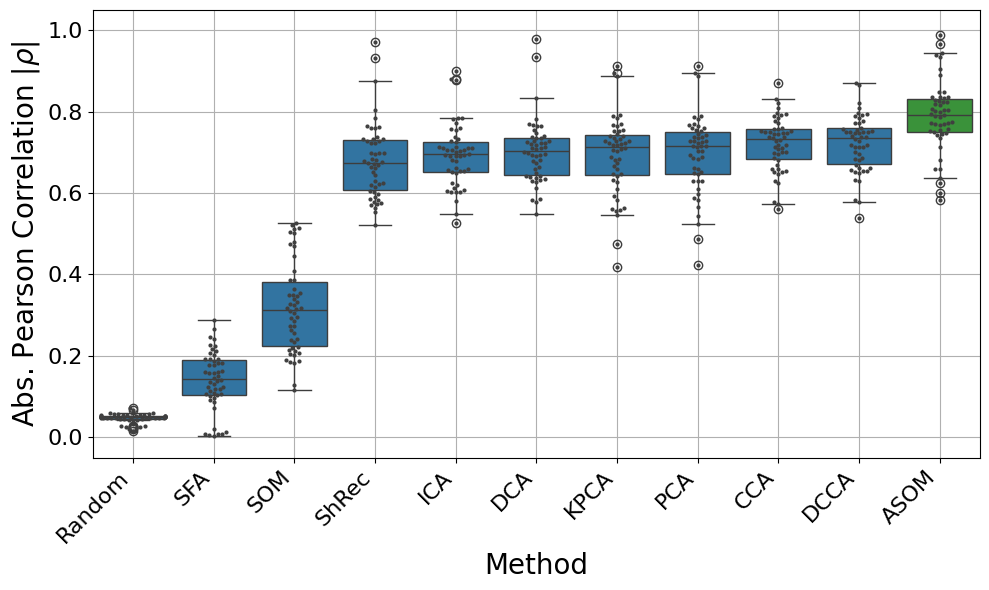

In [ ]:
df = pd.read_csv('unified_results.csv')
# df = pd.read_csv('../../results/final/logmaps_res.csv')



# chenge the logmap_fixed to logmap
# df['dataset'] = df['dataset'].replace('logmap_fixed', 'logmap')

# df = df[df['dataset'] == 'logmap']

# filter out the MaCo results
df = df[df['method'] != 'MaCo']

som_df = pd.read_csv('./CorrelationsSOM5Logist.txt', header=None, sep='\t')

df = integrate_somdata(df, som_df, dataset='logmap')
df2 = sort_by_med(df)
# df2 = df2**(1/2.)

# plot_res(df2, highlight=['ASOM'], filename='./logmaps_res.png')
plot_res(df2, highlight=['ASOM'], filename='./logmaps_res2.png')

## Tentmaps

/tmp/ipykernel_236103/2337597164.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right', fontsize=ticksize)
/tmp/ipykernel_236103/2337597164.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([r'{:.1f}'.format(i) for i in ax.get_yticks()], fontsize=ticksize)


(<Figure size 1000x600 with 1 Axes>,
 <Axes: xlabel='Method', ylabel='Abs. Pearson Correlation $|\\rho|$'>)

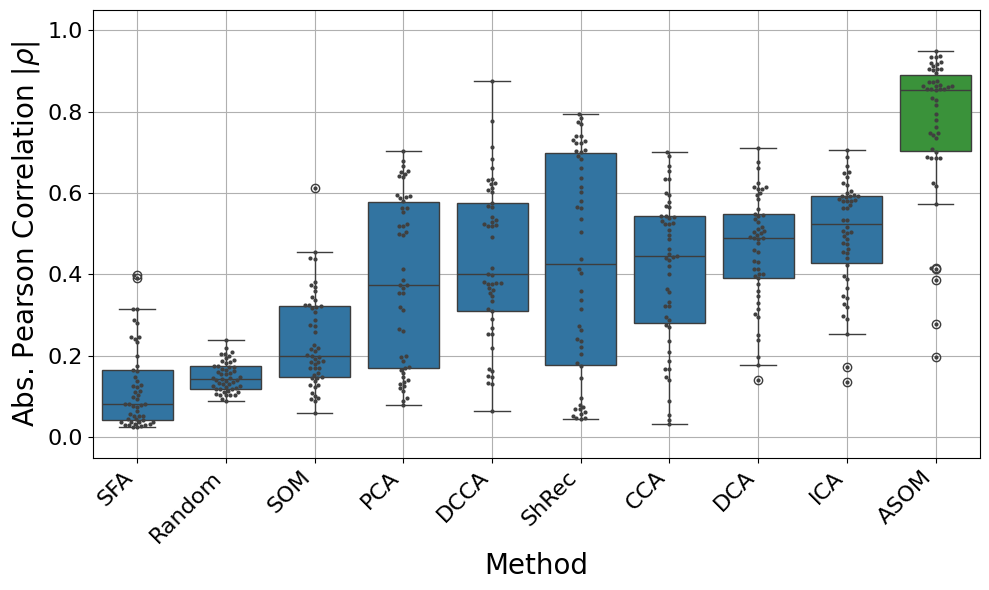

In [6]:
df = pd.read_csv('unified_results.csv')
# change the logmap_fixed to logmap
df['dataset'] = df['dataset'].replace('logmap_fixed', 'logmap')

df = df[df['dataset'] == 'tentmap']

# filter out the MaCo results
df = df[df['method'] != 'MaCo']

som_df = pd.read_csv('./CorrelationsSOM5Tent.txt', header=None, sep='\t')

df = integrate_somdata(df, som_df, dataset='tentmap')
df2 = sort_by_med(df)

plot_res(df2, highlight=['ASOM'], filename='./tentmaps_res.png')

## Unified Figure

In [10]:
df = pd.read_csv('unified_results.csv')
# change the logmap_fixed to logmap
df['dataset'] = df['dataset'].replace('logmap_fixed', 'logmap')
# filter out the MaCo results
df = df[df['method'] != 'MaCo']

som_df_tentmap = pd.read_csv('./CorrelationsSOM5Tent.txt', header=None, sep='\t')
som_df_logmap = pd.read_csv('./CorrelationsSOM5Logist.txt', header=None, sep='\t')


df = integrate_somdata(df, som_df_tentmap, dataset='tentmap')
df = integrate_somdata(df, som_df_logmap, dataset='logmap')


df2_tent = sort_by_med(df[df['dataset'] == 'tentmap'])
df2_log = sort_by_med(df[df['dataset'] == 'logmap'])


/home/zsiga/anaconda3/envs/maco_rev1/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 68.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/zsiga/anaconda3/envs/maco_rev1/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 6.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/tmp/ipykernel_236103/2337597164.py:59: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),
/tmp/ipykernel_236103/2337597164.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([r'{:.1f}'.format(i) for i in ax.get_yticks()], fontsize=ticksize)
/home/zsiga/anaconda3/envs/maco_rev1/lib

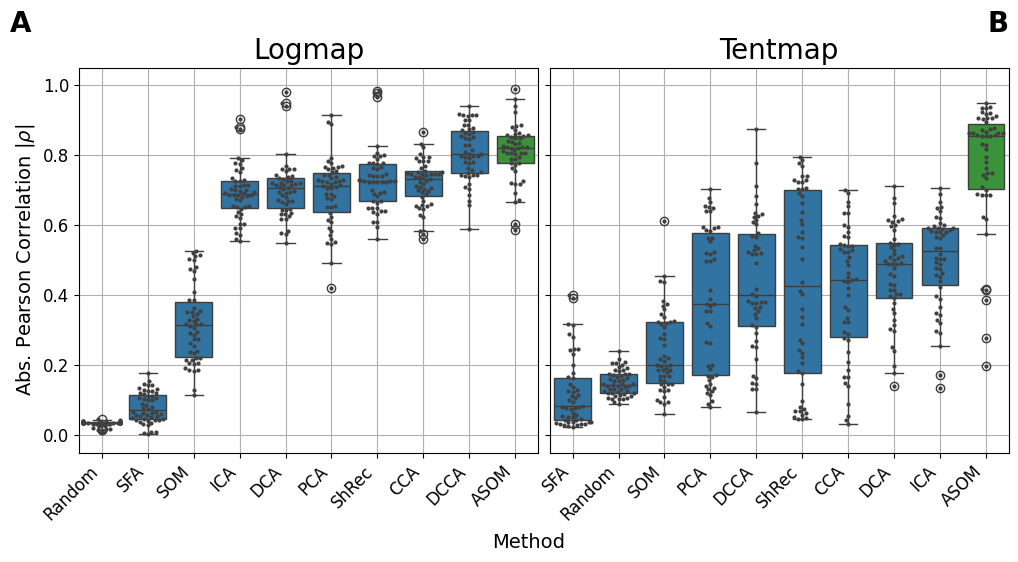

In [8]:
_ = plot_unified_res(df2_log, df2_tent, highlight=['ASOM'], filename='./unified_res.png')

## Compare length

In [9]:
df

,Unnamed: 0,data_id,r,method,dataset
0,0.0,0,0.700734,ICA,logmap
1,1.0,1,0.702184,ICA,logmap
2,2.0,2,0.711358,ICA,logmap
3,3.0,3,0.692003,ICA,logmap
4,4.0,4,0.577562,ICA,logmap
...,...,...,...,...,...
1795,NaN,45,0.294239,SOM,logmap
1796,NaN,46,0.255570,SOM,logmap
1797,NaN,47,0.186111,SOM,logmap
1798,NaN,48,0.332598,SOM,logmap


/tmp/ipykernel_1283265/4231527680.py:52: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  _ = sns.swarmplot(data=df_logmap, x='method', y='r', hue='length',
/home/zsiga/anaconda3/envs/maco_rev1/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 20.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


/home/zsiga/anaconda3/envs/maco_rev1/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 16.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


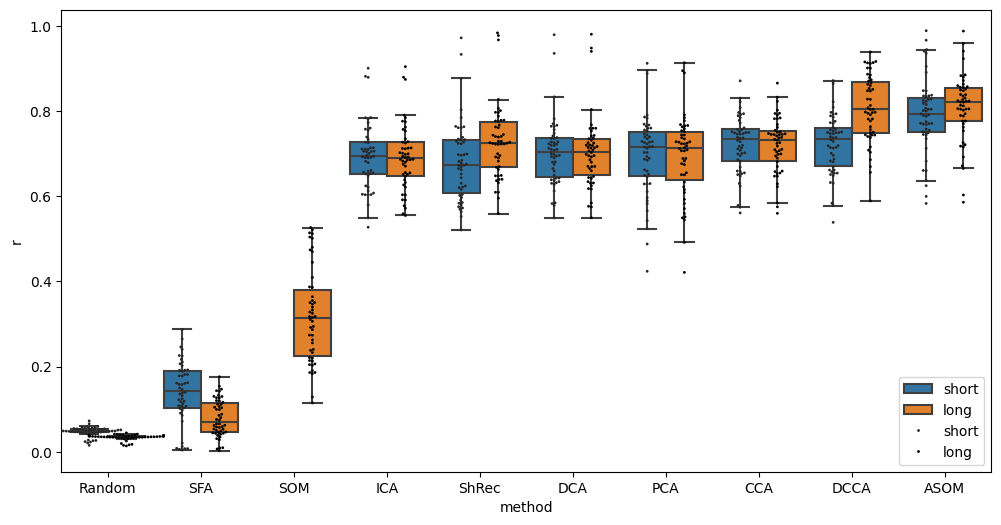

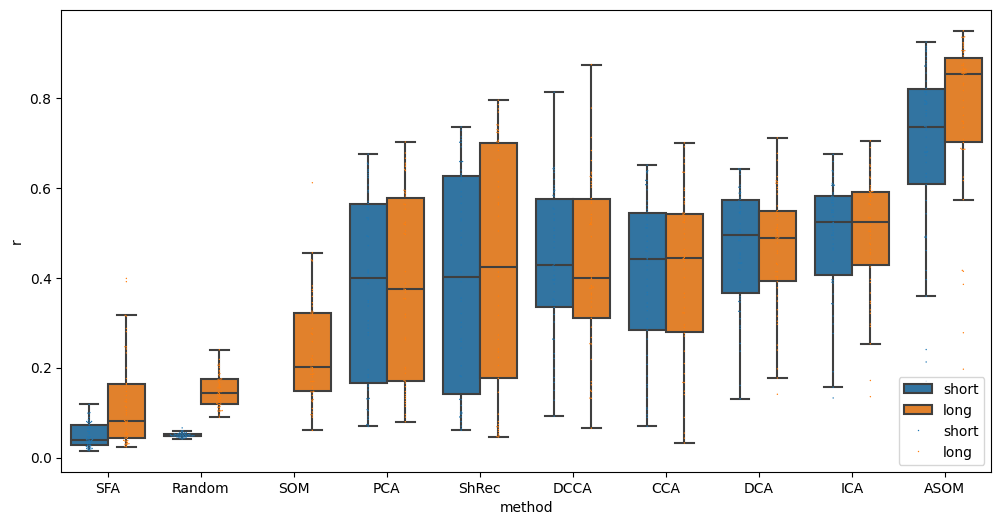

In [8]:
df = pd.read_csv('unified_results.csv', index_col=0)
# change the logmap_fixed to logmap
df['dataset'] = df['dataset'].replace('logmap_fixed', 'logmap')
# filter out the MaCo results
# df = df[df['method'] != 'MaCo']

som_df_tentmap = pd.read_csv('./CorrelationsSOM5Tent.txt', header=None, sep='\t')
som_df_logmap = pd.read_csv('./CorrelationsSOM5Logist.txt', header=None, sep='\t')


df = integrate_somdata(df, som_df_tentmap, dataset='tentmap')
df = integrate_somdata(df, som_df_logmap, dataset='logmap')
df_long = df.copy()
df_long['length'] = 'long'


df_short_log = pd.read_csv( final_res_path / 'logmaps_res.csv', index_col=0)
df_short_tent = pd.read_csv( final_res_path / 'tentmaps_res.csv', index_col=0)

# df_short_log
df_short = pd.concat([df_short_log, df_short_tent], axis=0, ignore_index=True)
df_short['length'] = 'short'

df = pd.concat([df_long, df_short], axis=0, ignore_index=True)
# display(df.head())


df = df[df['method'] != 'MaCo']

# compute the median
meds = df.groupby(['method', 'dataset', 'length']).median().reset_index().drop(columns=['data_id'])
# display(meds)
col_order_logmap = meds[meds['dataset'] == 'logmap'].groupby('method')['r'].mean().sort_values(ascending=True).index.to_list()
col_order_tentmap = meds[meds['dataset'] == 'tentmap'].groupby('method')['r'].mean().sort_values(ascending=True).index.to_list()



df_logmap = df[df['dataset'] == 'logmap']
df_tentmap = df[df['dataset'] == 'tentmap']

_ = plt.figure(figsize=(12, 6))
ax = plt.subplot(111)

# _ = sns.violinplot(df_logmap, x='method', y='r', hue='length', 
#                hue_order=['short', 'long'], order=col_order_logmap,
#                split=True, ax=ax, inner=None, width=2.5, density_norm='area', bw_method=0.2)

# boxplot
_ = sns.boxplot(df_logmap, x='method', y='r', hue='length',
                hue_order=['short', 'long'], order=col_order_logmap,
                dodge=True, ax=ax, linewidth=1.5, showfliers=False)
_ = sns.swarmplot(data=df_logmap, x='method', y='r', hue='length',
                hue_order=['short', 'long'], order=col_order_logmap,
                dodge=True, ax=ax, size=2, color='black')

ax.legend(loc='lower right')

_ = plt.figure(figsize=(12, 6))
ax = plt.subplot(111)

# _ = sns.violinplot(df_tentmap, x='method', y='r', hue='length', 
#                hue_order=['short', 'long'], order=col_order_tentmap,
#                split=False, ax=ax, inner=None, width=1., density_norm='width', bw_method=0.2)
_ = sns.boxplot(df_tentmap, x='method', y='r', hue='length',
                hue_order=['short', 'long'], order=col_order_tentmap,
                dodge=True, ax=ax, linewidth=1.5, showfliers=False)
_ = sns.swarmplot(data=df_tentmap, x='method', y='r', hue='length',
                hue_order=['short', 'long'], order=col_order_tentmap,
                dodge=True, ax=ax, size=1)

ax.legend(loc='lower right')


# Table with results

In [9]:
# apply multiple functions to the r column
def iqr(x):
    return x.quantile(0.75) - x.quantile(0.25)

def mad(x):
    '''Computes median absolute distance from the median'''
    return (x - x.median()).abs().median()


df = pd.read_csv('unified_results.csv', index_col=0)
df['dataset'] = df['dataset'].replace('logmap_fixed', 'logmap')

som_df_tentmap_short = pd.read_csv('./SOM_Tent_Cors_5000.txt', header=None, sep='\t')
som_df_logmap_short = pd.read_csv('./SOM_Logist_Cors_5000.txt', header=None, sep='\t')

som_df_tentmap_long = pd.read_csv('./SOM_Tent_Cors_16000.txt', header=None, sep='\t')
som_df_logmap_long = pd.read_csv('./SOM_Logist_Cors_16000.txt', header=None, sep='\t')


df = integrate_somdata(df, som_df_tentmap_long, dataset='tentmap')
df = integrate_somdata(df, som_df_logmap_long, dataset='logmap')
df_long = df.copy()
df_long['length'] = 'long'




df_short_log = pd.read_csv( final_res_path / 'logmaps_res.csv', index_col=0)
df_short_tent = pd.read_csv( final_res_path / 'tentmaps_res.csv', index_col=0)

# df_short_log
df_short = pd.concat([df_short_log,
                      df_short_tent],
                      axis=0, ignore_index=True)

df_short =  integrate_somdata(df_short,
                              som_df_tentmap_short,
                              dataset='tentmap')
df_short =  integrate_somdata(df_short,
                              som_df_logmap_short,
                              dataset='logmap')
df_short['length'] = 'short'

df = pd.concat([df_long, df_short], axis=0, ignore_index=True)
# display(df.head())


df = df[df['method'] != 'MaCo']


df_filtered = df[(df.dataset == 'logmap') | (df.dataset == 'tentmap')]
means = df_filtered.sort_values(by='method', ascending=True, inplace=False).groupby(['dataset',
                                                                                     'method',
                                                                                     'length'])['r'].agg(['median',
                                                                                                          mad]).reset_index()
# display(means)

means.to_csv('./median_mad.csv')

['ICA-long', 'ICA-long', 'ICA-long', 'ICA-long', 'ICA-long']
['short', 'long']


/tmp/ipykernel_1283265/1097737738.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),
/tmp/ipykernel_1283265/1097737738.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([r'{:.1f}'.format(i) for i in ax.get_yticks()], fontsize=12)
/tmp/ipykernel_1283265/1097737738.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),
/tmp/ipykernel_1283265/1097737738.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([r'{:.1f}'.format(i) for i in ax.get_yticks()], fontsize=12)


['ICA-long', 'ICA-long', 'ICA-long', 'ICA-long', 'ICA-long']
['short', 'long']


/tmp/ipykernel_1283265/1097737738.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),
/tmp/ipykernel_1283265/1097737738.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([r'{:.1f}'.format(i) for i in ax.get_yticks()], fontsize=12)
/tmp/ipykernel_1283265/1097737738.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),
/tmp/ipykernel_1283265/1097737738.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([r'{:.1f}'.format(i) for i in ax.get_yticks()], fontsize=12)


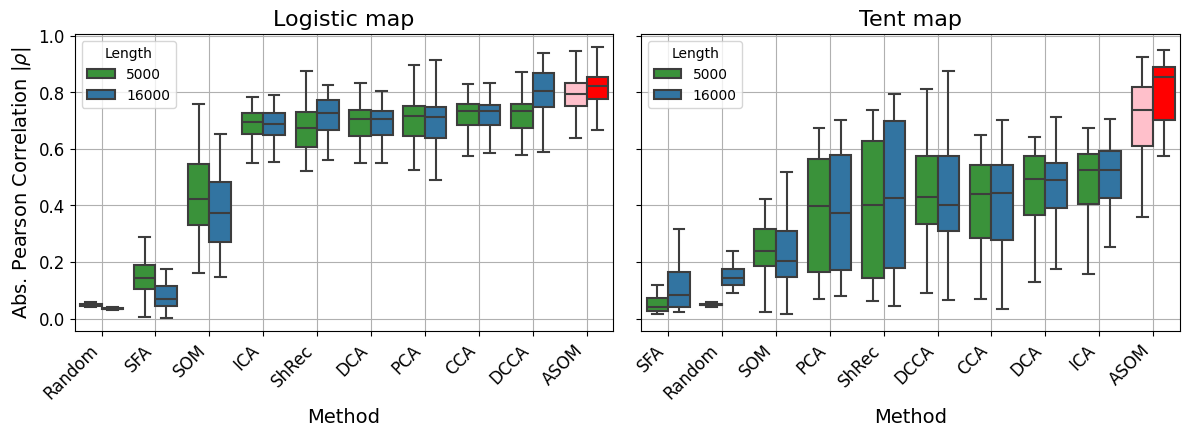

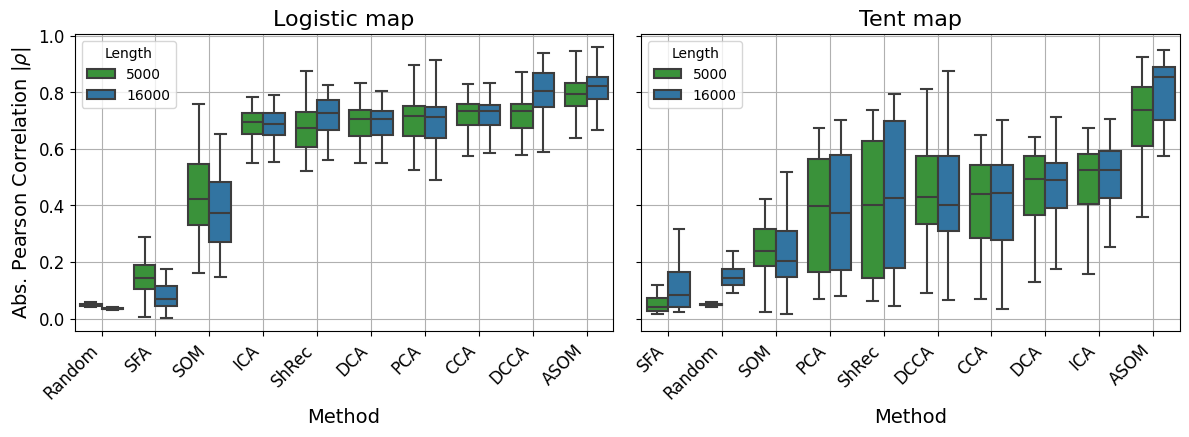

In [10]:

for marked in [True, False]:
    color_dict = {'short': 'tab:green', 'long': 'tab:blue'}


    df['huevar'] = df.apply(lambda row: row['method']+"-"+row['length'], axis=1)
    print(df.huevar.head().to_list())

    fig = plt.figure(figsize=(12, 8))
    ax1 = plt.subplot(221)

    # _ = sns.violinplot(df_logmap, x='method', y='r', hue='length', 
    #                hue_order=['short', 'long'], order=col_order_logmap,
    #                split=True, ax=ax, inner=None, width=2.5, density_norm='area', bw_method=0.2)

    # boxplot
    _ = sns.boxplot(df[df.dataset=='logmap'], x='method', y='r', hue='length',
                    hue_order=['short', 'long'], order=col_order_logmap,
                    dodge=True, ax=ax1, linewidth=1.5, showfliers=False, legend=True, palette=color_dict)

    ax2 = plt.subplot(222, sharey=ax1)

    _ = sns.boxplot(df[df.dataset=='tentmap'], x='method', y='r', hue='length',
                    hue_order=['short', 'long'], order=col_order_tentmap,
                    dodge=True, ax=ax2, linewidth=1.5, showfliers=False, palette=color_dict)

    # # recolor the last box in the boxplot
    if marked:
        ax1.get_children()[54].set_facecolor('pink')
        ax1.get_children()[114].set_facecolor('red')

        ax2.get_children()[54].set_facecolor('pink')
        ax2.get_children()[114].set_facecolor('red')


    # clear ax2 labels
    ax2.set_ylabel('')
    # labelleft false
    ax2.tick_params(labelleft=False)

    ax1.grid(True)
    ax2.grid(True)

    handles, labels = ax2.get_legend_handles_labels()
    print(labels)
    ax1.legend(handles=handles, 
            labels=[5000, 16000] ,loc='upper left', title='Length')
    ax2.legend(handles=handles, 
            labels=[5000, 16000] ,loc='upper left', title='Length')

    ax1.set_title('Logistic map', fontsize=16)
    ax2.set_title('Tent map', fontsize=16)

    # set label and ticklabel sizes to bigger
    for ax in [ax1, ax2]:
        ax.set_xlabel('Method', fontsize=14)
        ax.set_xticklabels(ax.get_xticklabels(),
                        rotation=45,
                        verticalalignment='top', 
                        horizontalalignment='right',
                        fontsize=12)
        ax.set_yticklabels([r'{:.1f}'.format(i) for i in ax.get_yticks()], fontsize=12)

    ax1.set_ylabel(r'Abs. Pearson Correlation $|\rho|$', fontsize=14)

    fig.tight_layout(rect=[0, 0, 1, 0.95])

    if marked:
        fig.savefig('./unified_res_marked.png', dpi=300, bbox_inches='tight')
        # also in pdf
        fig.savefig('./unified_res_marked.pdf', dpi=300, bbox_inches='tight')

    else:
        fig.savefig('./unified_res.png', dpi=300, bbox_inches='tight')
        # also in pdf
        fig.savefig('./unified_res.pdf', dpi=300, bbox_inches='tight')

In [236]:
import matplotlib

In [255]:
inds = [j for j, i in enumerate(ax1.get_children()) if type(i) == matplotlib.patches.PathPatch]
print(len(inds))

inds2 = [j for j, i in enumerate(ax2.get_children()) if type(i) == matplotlib.patches.PathPatch]
print(len(inds2))
print(inds2[9], inds2[19])

20
20
54 114


In [160]:
# define index as method, dataset and length
mdf = means.set_index(['dataset','length', 'method'], inplace=False).sort_values(by=['dataset', 'length', 'method'],
                                                                                 ascending=True)
# round values to 2 decimal places
mdf = mdf.round(3)

def merge(row):
    return f'{row["median"]:.3f} ± {row["mad"]:.3f}'

# merge the median and mad two columns with +- sign as str
mdf['performance'] = mdf.apply(merge, axis=1)
mdf.drop(columns=['median', 'mad'], inplace=True)

# transpose
mdf = mdf.unstack(level=[0, 1])
# drop the performance level in index
mdf = mdf.T.droplevel(0).T

# change the names in the header long --> n=16k, short --> n=5k on the 2nd level
# get the level order and change the names in the list, then set the new names
col_list = mdf.columns.levels[1].to_list()
# replace the names
repl_dict = {'long': 'n=16k', 'short': 'n=5k'}
new_col_list = [repl_dict[col] for col in col_list]
mdf.columns = mdf.columns.set_levels(new_col_list, level=1)

# clear the name of levels
# mdf.columns.names = [None, None]
mdf.index.names = [None]
mdf.columns.names = [None, None]

mdf


logmap                       tentmap               
                n=16k           n=5k          n=16k           n=5k
ASOM    0.821 ± 0.036  0.792 ± 0.041  0.854 ± 0.068  0.736 ± 0.115
CCA     0.732 ± 0.037  0.734 ± 0.038  0.444 ± 0.124  0.441 ± 0.125
DCA     0.705 ± 0.037  0.704 ± 0.041  0.489 ± 0.089  0.494 ± 0.088
DCCA    0.804 ± 0.060  0.735 ± 0.044  0.400 ± 0.144  0.428 ± 0.125
ICA     0.689 ± 0.038  0.695 ± 0.041  0.525 ± 0.072  0.525 ± 0.064
PCA     0.713 ± 0.052  0.716 ± 0.050  0.374 ± 0.206  0.399 ± 0.199
Random  0.035 ± 0.002  0.049 ± 0.004  0.144 ± 0.027  0.049 ± 0.003
SFA     0.070 ± 0.032  0.143 ± 0.043  0.082 ± 0.046  0.040 ± 0.018
SOM     0.372 ± 0.110  0.423 ± 0.109  0.202 ± 0.085  0.240 ± 0.061
ShRec   0.725 ± 0.052  0.674 ± 0.059  0.425 ± 0.271  0.402 ± 0.228

In [161]:
# Generate a LaTeX table median +- mad
mdf.to_latex('./median_mad.tex',
             bold_rows=True,
             float_format="%.2f",
             escape=False)


# UPDATE dataframe with KPCA results


In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import sys
sys.path.append('../../')
from scripts.resgen.logmaps.config_logmapres import final_res_path, figure_path

def mad(x):
    '''Computes median absolute distance from the median'''
    return (x - x.median()).abs().median()

In [11]:
df = pd.read_csv('unified_results.csv', index_col=0)
df['dataset'] = df['dataset'].replace('logmap_fixed', 'logmap')
columns = df.columns.to_list()

som_df_tentmap_short = pd.read_csv('./SOM_Tent_Cors_5000.txt', header=None, sep='\t')
som_df_logmap_short = pd.read_csv('./SOM_Logist_Cors_5000.txt', header=None, sep='\t')

# kpca_df_tentmap_short = pd.read_csv('../../results/interim/tentmaps/kpca_5k_res.csv', index_col=0)[columns]
# kpca_df_logmap_short = pd.read_csv('../../results/interim/logmaps/kpca_5k_res.csv', index_col=0)[columns]
# the short is already included

som_df_tentmap_long = pd.read_csv('./SOM_Tent_Cors_16000.txt', header=None, sep='\t')
som_df_logmap_long = pd.read_csv('./SOM_Logist_Cors_16000.txt', header=None, sep='\t')

kpca_df_tentmap_long = pd.read_csv('../../results/interim/tentmaps/kpca_16k_res.csv')[columns]
kpca_df_logmap_long = pd.read_csv('../../results/interim/logmaps/kpca_16k_res.csv')[columns]

kpca_df_tentmap_long['dataset'] = 'tentmap'
kpca_df_logmap_long['dataset'] = 'logmap'


# som_df_logmap_short
# kpca_df_logmap_long
# df

df = pd.concat([df, kpca_df_tentmap_long, kpca_df_logmap_long], axis=0, ignore_index=True)

df = integrate_somdata(df, som_df_tentmap_long, dataset='tentmap')
df = integrate_somdata(df, som_df_logmap_long, dataset='logmap')
df_long = df.copy()
df_long['length'] = 'long'

df_long.method.unique()


df_short_log = pd.read_csv( final_res_path / 'logmaps_res.csv', index_col=0)
df_short_tent = pd.read_csv( final_res_path / 'tentmaps_res.csv', index_col=0)

# df_short_log
df_short = pd.concat([df_short_log,
                      df_short_tent],
                      axis=0, ignore_index=True)

df_short =  integrate_somdata(df_short,
                              som_df_tentmap_short,
                              dataset='tentmap')
df_short =  integrate_somdata(df_short,
                              som_df_logmap_short,
                              dataset='logmap')
df_short['length'] = 'short'

# df_short.method.unique()

df = pd.concat([df_long, df_short], axis=0, ignore_index=True)
# display(df.head())


df = df[df['method'] != 'MaCo']


df_filtered = df[(df.dataset == 'logmap') | (df.dataset == 'tentmap')]
means = df_filtered.sort_values(by='method', ascending=True, inplace=False).groupby(['dataset',
                                                                                     'method',
                                                                                     'length'])['r'].agg(['median',
                                                                                                          mad]).reset_index()

means.to_csv('./median_mad_updated.csv')
means

,dataset,method,length,median,mad
0,logmap,ASOM,long,0.820968,0.035506
1,logmap,ASOM,short,0.792212,0.041019
2,logmap,CCA,long,0.732416,0.036951
3,logmap,CCA,short,0.733526,0.038277
4,logmap,DCA,long,0.704572,0.037293
5,logmap,DCA,short,0.703934,0.041308
6,logmap,DCCA,long,0.803747,0.059903
7,logmap,DCCA,short,0.734940,0.044385
8,logmap,ICA,long,0.688938,0.038455
9,logmap,ICA,short,0.694885,0.040924


['ICA-long', 'ICA-long', 'ICA-long', 'ICA-long', 'ICA-long']
['short', 'long']


/tmp/ipykernel_4020372/1781362473.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),
/tmp/ipykernel_4020372/1781362473.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([r'{:.1f}'.format(i) for i in ax.get_yticks()], fontsize=12)
/tmp/ipykernel_4020372/1781362473.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),
/tmp/ipykernel_4020372/1781362473.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([r'{:.1f}'.format(i) for i in ax.get_yticks()], fontsize=12)


['ICA-long', 'ICA-long', 'ICA-long', 'ICA-long', 'ICA-long']
['short', 'long']


/tmp/ipykernel_4020372/1781362473.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),
/tmp/ipykernel_4020372/1781362473.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([r'{:.1f}'.format(i) for i in ax.get_yticks()], fontsize=12)
/tmp/ipykernel_4020372/1781362473.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),
/tmp/ipykernel_4020372/1781362473.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([r'{:.1f}'.format(i) for i in ax.get_yticks()], fontsize=12)


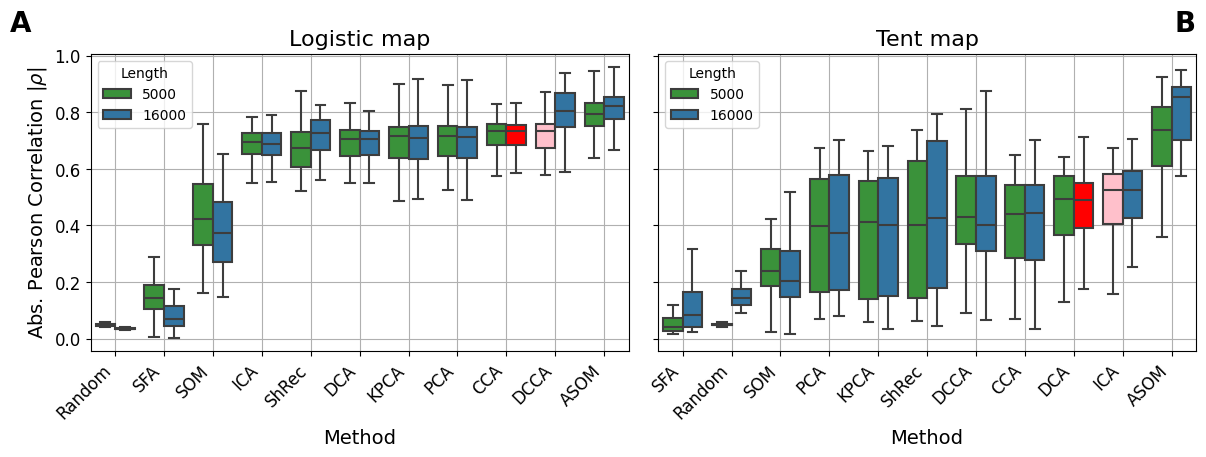

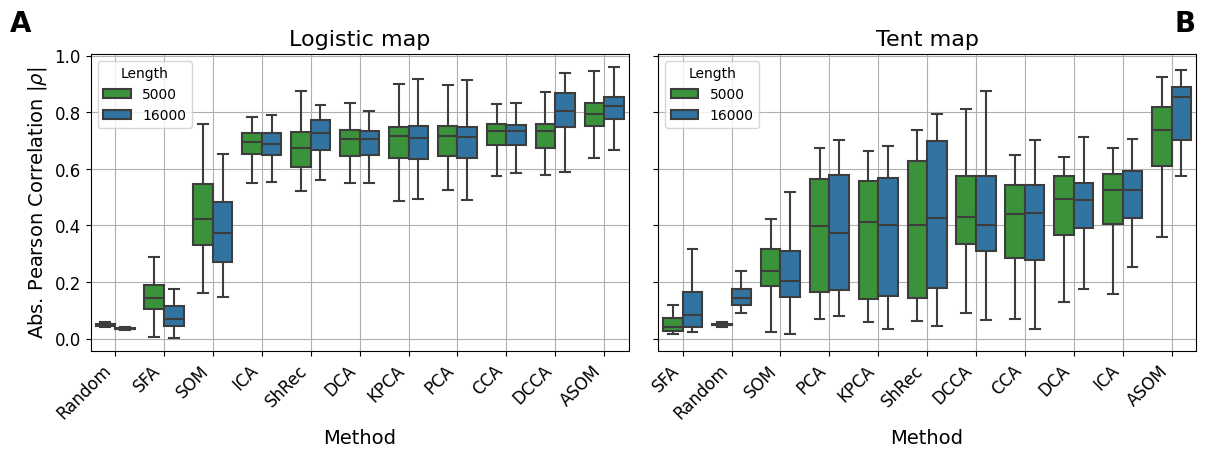

In [12]:
meds = df.groupby(['method', 'dataset', 'length']).median().reset_index().drop(columns=['data_id'])
# display(meds)
col_order_logmap = meds[meds['dataset'] == 'logmap'].groupby('method')['r'].mean().sort_values(ascending=True).index.to_list()
col_order_tentmap = meds[meds['dataset'] == 'tentmap'].groupby('method')['r'].mean().sort_values(ascending=True).index.to_list()



for marked in [True, False]:
    color_dict = {'short': 'tab:green', 'long': 'tab:blue'}


    df['huevar'] = df.apply(lambda row: row['method']+"-"+row['length'], axis=1)
    print(df.huevar.head().to_list())

    fig = plt.figure(figsize=(12, 8))
    ax1 = plt.subplot(221)

    # _ = sns.violinplot(df_logmap, x='method', y='r', hue='length', 
    #                hue_order=['short', 'long'], order=col_order_logmap,
    #                split=True, ax=ax, inner=None, width=2.5, density_norm='area', bw_method=0.2)

    # boxplot
    _ = sns.boxplot(df[df.dataset=='logmap'], x='method', y='r', hue='length',
                    hue_order=['short', 'long'], order=col_order_logmap,
                    dodge=True, ax=ax1, linewidth=1.5, showfliers=False, legend=True, palette=color_dict)

    ax2 = plt.subplot(222, sharey=ax1)

    _ = sns.boxplot(df[df.dataset=='tentmap'], x='method', y='r', hue='length',
                    hue_order=['short', 'long'], order=col_order_tentmap,
                    dodge=True, ax=ax2, linewidth=1.5, showfliers=False, palette=color_dict)

    # # recolor the last box in the boxplot
    if marked:
        ax1.get_children()[54].set_facecolor('pink')
        ax1.get_children()[114].set_facecolor('red')

        ax2.get_children()[54].set_facecolor('pink')
        ax2.get_children()[114].set_facecolor('red')


    # clear ax2 labels
    ax2.set_ylabel('')
    # labelleft false
    ax2.tick_params(labelleft=False)

    ax1.grid(True)
    ax2.grid(True)

    handles, labels = ax2.get_legend_handles_labels()
    print(labels)
    ax1.legend(handles=handles, 
            labels=[5000, 16000] ,loc='upper left', title='Length')
    ax2.legend(handles=handles, 
            labels=[5000, 16000] ,loc='upper left', title='Length')

    ax1.set_title('Logistic map', fontsize=16)
    ax2.set_title('Tent map', fontsize=16)

    # set label and ticklabel sizes to bigger
    for ax in [ax1, ax2]:
        ax.set_xlabel('Method', fontsize=14)
        ax.set_xticklabels(ax.get_xticklabels(),
                        rotation=45,
                        verticalalignment='top', 
                        horizontalalignment='right',
                        fontsize=12)
        ax.set_yticklabels([r'{:.1f}'.format(i) for i in ax.get_yticks()], fontsize=12)

    ax1.set_ylabel(r'Abs. Pearson Correlation $|\rho|$', fontsize=14)

    fig.tight_layout(rect=[0, 0, 1, 0.95])

    # Put A and B
    ax1.text(-0.15, 1.15, 'A', transform=ax1.transAxes, fontsize=20, fontweight='bold', va='top', ha='left')
    ax2.text(1., 1.15, 'B', transform=ax2.transAxes, fontsize=20, fontweight='bold', va='top', ha='right')

    if marked:
        fig.savefig('./unified_res_marked.png', dpi=300, bbox_inches='tight')
        # also in pdf
        fig.savefig('./unified_res_marked.pdf', dpi=300, bbox_inches='tight')

    else:
        fig.savefig('./unified_res.png', dpi=300, bbox_inches='tight')
        # also in pdf
        fig.savefig('./unified_res.pdf', dpi=300, bbox_inches='tight')


In [13]:
# define index as method, dataset and length
mdf = means.set_index(['dataset','length', 'method'], inplace=False).sort_values(by=['dataset', 'length', 'method'],
                                                                                 ascending=True)
# round values to 2 decimal places
mdf = mdf.round(3)

def merge(row):
    return f'{row["median"]:.3f} ± {row["mad"]:.3f}'

# merge the median and mad two columns with +- sign as str
mdf['performance'] = mdf.apply(merge, axis=1)
mdf.drop(columns=['median', 'mad'], inplace=True)

# transpose
mdf = mdf.unstack(level=[0, 1])
# drop the performance level in index
mdf = mdf.T.droplevel(0).T

# change the names in the header long --> n=16k, short --> n=5k on the 2nd level
# get the level order and change the names in the list, then set the new names
col_list = mdf.columns.levels[1].to_list()
# replace the names
repl_dict = {'long': 'n=16k', 'short': 'n=5k'}
new_col_list = [repl_dict[col] for col in col_list]
mdf.columns = mdf.columns.set_levels(new_col_list, level=1)

# clear the name of levels
# mdf.columns.names = [None, None]
mdf.index.names = [None]
mdf.columns.names = [None, None]
display(mdf)


# Generate a LaTeX table median +- mad
mdf.to_latex('./median_mad_updated.tex',
             bold_rows=True,
             float_format="%.2f",
             escape=False)

logmap                       tentmap               
                n=16k           n=5k          n=16k           n=5k
ASOM    0.821 ± 0.036  0.792 ± 0.041  0.854 ± 0.068  0.736 ± 0.115
CCA     0.732 ± 0.037  0.734 ± 0.038  0.444 ± 0.124  0.441 ± 0.125
DCA     0.705 ± 0.037  0.704 ± 0.041  0.489 ± 0.089  0.494 ± 0.088
DCCA    0.804 ± 0.060  0.735 ± 0.044  0.400 ± 0.144  0.428 ± 0.125
ICA     0.689 ± 0.038  0.695 ± 0.041  0.525 ± 0.072  0.525 ± 0.064
KPCA    0.710 ± 0.051  0.715 ± 0.048  0.403 ± 0.184  0.410 ± 0.177
PCA     0.713 ± 0.052  0.716 ± 0.050  0.374 ± 0.206  0.399 ± 0.199
Random  0.035 ± 0.002  0.049 ± 0.004  0.144 ± 0.027  0.049 ± 0.003
SFA     0.070 ± 0.032  0.143 ± 0.043  0.082 ± 0.046  0.040 ± 0.018
SOM     0.372 ± 0.110  0.423 ± 0.109  0.202 ± 0.085  0.240 ± 0.061
ShRec   0.725 ± 0.052  0.674 ± 0.059  0.425 ± 0.271  0.402 ± 0.228

In [14]:
import os
os.cpu_count()

24